# Building Micrograd from Scratch with Andrej Karpathy

In [105]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [106]:
def f(x):
    return 3*x**2 - 4*x + 5

In [107]:
f(3.0)

20.0

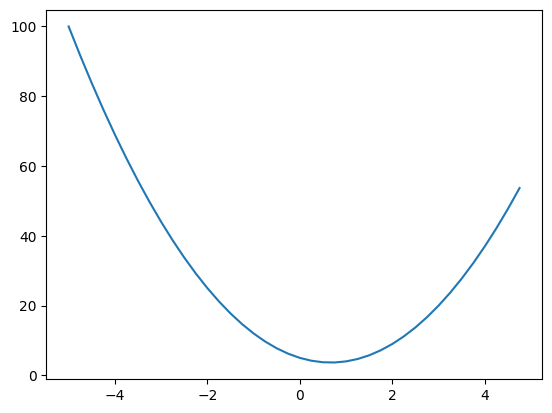

In [108]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [109]:
h = 0.001
x = 3.0
(f(x + h) - f(x - h)) / 2 * h

1.3999999999999346e-05

In [110]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [111]:
h = 0.0001

d1 = a*b + c
b += h
d2 = a*b + c
print("d1:", d1)
print("d2:", d2)

print((d2 - d1) / h)

d1: 4.0
d2: 4.0002
2.0000000000042206


In [112]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = _children
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0, label=L)

In [113]:
o = L.tanh(); o.label = "o"
o

Value(data=-0.9999997749296758, label=o)

In [114]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [115]:
L.grad = 1.0
# L._backward()
# d._backward()
# e._backward()

In [116]:
# topo = []
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(L)
# topo

In [117]:
# for node in reversed(topo):
#     node._backward()

In [118]:
L.backward()

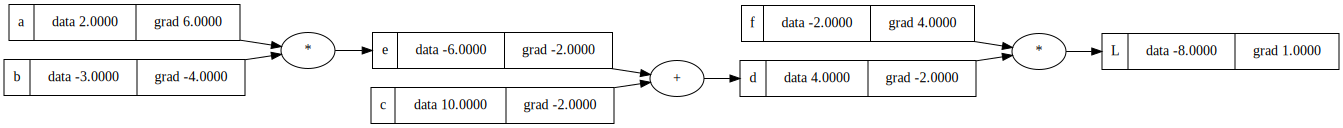

In [119]:
draw_dot(L)

In [120]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=2.0, label=a),
 Value(data=-3.0, label=b),
 Value(data=-6.0, label=e),
 Value(data=10.0, label=c),
 Value(data=4.0, label=d),
 Value(data=-2.0, label=f),
 Value(data=-8.0, label=L),
 Value(data=-0.9999997749296758, label=o)]

Uing PYtorch

In [121]:
from torch import Tensor, tanh

In [122]:
x1 = Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = Tensor([1.0]).double()                ; w2.requires_grad = True
b = Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


Neuron

In [123]:
import random

In [124]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.6372825715936306, label=)

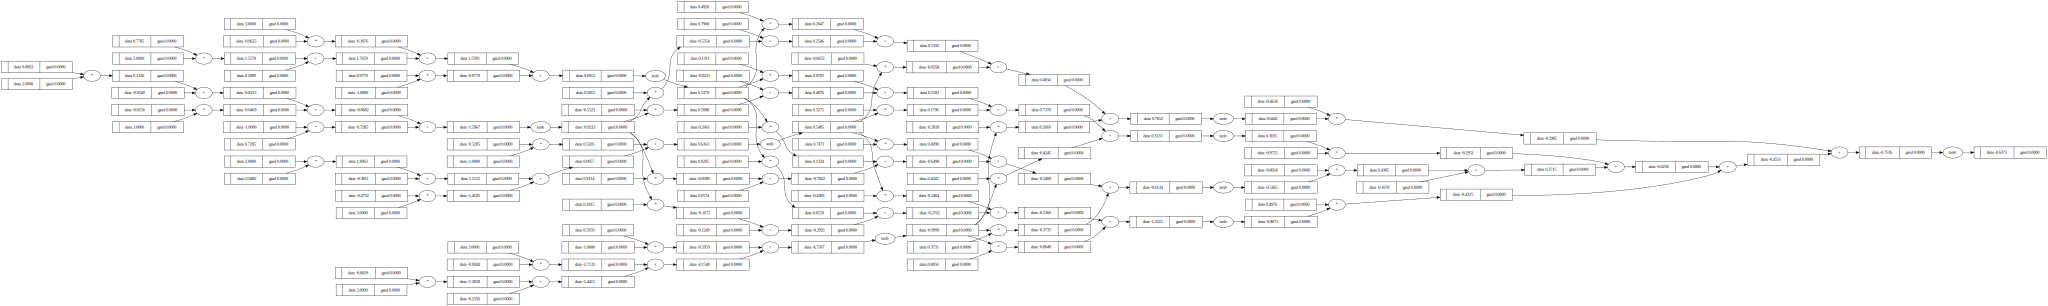

In [125]:
draw_dot(n(x))

In [126]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.6372825715936306, label=),
 Value(data=-0.9250925944876407, label=),
 Value(data=0.03030771417050426, label=),
 Value(data=-0.47940355941701035, label=)]

In [127]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=2.680694219244252, label=),
 Value(data=0.005611119400593037, label=),
 Value(data=1.0615339858792492, label=),
 Value(data=2.1886348916157194, label=)]

In [128]:
loss =sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=5.936474216139814, label=)

In [129]:
loss.backward()

In [130]:
n.layers[0].neurons[0].w[0].grad

0.16191522966280436

In [131]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 5.936474216139814
1 3.1115312860857465
2 1.08350065293578
3 0.11805483305424852
4 0.032185244620945595
5 0.024458291392622945
6 0.02034326231735589
7 0.017695795282833222
8 0.015810440579579428
9 0.014378694074082893
10 0.013242089477646055
11 0.012310089510057982
12 0.01152684949767335
13 0.0108558595609765
14 0.010272128769354323
15 0.009757901533052778
16 0.00930016725424768
17 0.008889140974018096
18 0.008517298312317532
19 0.008178741137171682


In [132]:
ypred

[Value(data=0.9602151531716749, label=),
 Value(data=-0.9866480408135034, label=),
 Value(data=-0.9341685882549692, label=),
 Value(data=0.9543507117957274, label=)]